## Name : Warish Ali
## Roll : ACE079BCT079
## Program : BCT 'B'

# Project Title : Comparative Analysis of Classification Algorithms in Data Mining

## Introduction
Classification is a fundamental data mining technique used to predict the group membership of data instances. Its primary goal is to accurately predict the target class for each case in the data by assigning items in a collection to target categories or classes.

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

## Dataset Description
For this project, the **Palmer Penguins Dataset** is used. It is a well-known multivariate dataset containing 344 instances (rows) and a mix of numerical and categorical attributes, including Bill Length, Bill Depth, Flipper Length, Body Mass, Island, and Sex. The target variable has 3 classes: *Adelie*, *Chinstrap*, and *Gentoo*. This dataset is ideal for demonstrating classification because it introduces realistic data mining challenges, such as handling missing values and encoding categorical variables, providing a much more robust and practical test of the preprocessing and classification pipeline than perfectly clean datasets.

In [2]:
if not os.path.exists('dataset'):
    os.makedirs('dataset')

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
file_path = "dataset/penguins.csv"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

df = pd.read_csv(file_path)

numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['island', 'sex']

num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

df = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

feature_names = list(df.drop('species', axis=1).columns)
X = df.drop('species', axis=1).values
y = df['species'].map({'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Classification Methods Applied

Following classification methods are implemented and compared:

1. **Decision Tree Classifier**: Builds a tree structure where internal nodes represent attribute tests (using Gini-Index as per CART algorithm) and leaf nodes represent class labels. To prevent overfitting (where the model learns noise instead of underlying relationships), **pre-pruning** is applied by limiting `max_depth=4` to reduce tree complexity before it fully grows.

2. **Rule-Based Classifier (Indirect Method)**: Classifies records using a collection of "If… Then…" rules extracted directly from a trained Decision Tree. Instead of using complex direct algorithms like RIPPER, we utilized the Indirect Method to generate interpretable rule sets based on actual penguin features (e.g., *If flipper_length <= -0.45 Then Adelie*). This satisfies the syllabus requirement for rule ordering and default classes while maintaining full interpretability.

3. **k-Nearest Neighbor (k-NN) Classifier**: An instance-based learner that classifies an unknown tuple by finding the 'k' closest training tuples in the pattern space using Euclidean distance. The class is determined by a majority vote. Feature scaling was strictly applied here to prevent attributes with larger magnitudes (like body mass) from dominating the distance calculation.

4. **Naive Bayesian Classifier**: A statistical classifier based on Bayes’ Theorem. It predicts class membership probabilities by assuming class conditional independence (the effect of an attribute value on a given class is independent of other attributes). It maximizes $$ P(X \mid C_i) P(C_i) $$ to determine the most probable class.

5. **Artificial Neural Network (ANN) Classifier**: A connectionist model consisting of input, hidden, and output layers. It uses the Backpropagation algorithm to iteratively adjust connection weights and minimize error. To avoid overfitting on this small dataset, **L2 regularization (`alpha=0.1`)** was applied alongside a reduced hidden layer size `(8,)`, forcing the network to generalize rather than memorize.

In [3]:
class IndirectRuleBasedClassifier:
    def __init__(self):
        self.tree = DecisionTreeClassifier(max_depth=3, random_state=42)

    def fit(self, X, y, print_rules=False):
        self.tree.fit(X, y)
        if print_rules:
            print("Extracted Rules (Indirect Method from Decision Tree):")
            print(export_text(self.tree, feature_names=feature_names))

    def predict(self, X):
        return self.tree.predict(X)

models = {
    "Decision Tree (Pre-pruned)": DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42),
    "Rule Based (Indirect Method)": IndirectRuleBasedClassifier(),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Artificial Neural Network": MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000, alpha=0.1, random_state=42)
}

print("Models initialized:")
for name in models.keys():
    print(f"  - {name}")

Models initialized:
  - Decision Tree (Pre-pruned)
  - Rule Based (Indirect Method)
  - k-Nearest Neighbors
  - Naive Bayes
  - Artificial Neural Network


In [4]:
print("\nSECTION 1: MODEL VALIDATION")
print("Using 5-Fold Cross-Validation\n")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
validation_results = {}

for name, model in models.items():
    print(f"Validating {name}...")

    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled), 1):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model.fit(X_fold_train, y_fold_train)
        y_fold_pred = model.predict(X_fold_val)
        score = accuracy_score(y_fold_val, y_fold_pred)
        fold_scores.append(score)

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    validation_results[name] = {
        'fold_scores': fold_scores,
        'mean': mean_score,
        'std': std_score
    }

    print(f"  Fold accuracies: {[round(s, 4) for s in fold_scores]}")
    print(f"  Mean: {round(mean_score, 4)} (+/- {round(std_score, 4)})\n")


SECTION 1: MODEL VALIDATION
Using 5-Fold Cross-Validation

Validating Decision Tree (Pre-pruned)...
  Fold accuracies: [0.875, 0.8958, 0.9375, 0.9375, 0.9583]
  Mean: 0.9208 (+/- 0.0306)

Validating Rule Based (Indirect Method)...
  Fold accuracies: [0.9792, 0.8958, 0.9583, 0.9167, 0.9375]
  Mean: 0.9375 (+/- 0.0295)

Validating k-Nearest Neighbors...
  Fold accuracies: [0.9792, 1.0, 0.9792, 1.0, 0.9792]
  Mean: 0.9875 (+/- 0.0102)

Validating Naive Bayes...
  Fold accuracies: [0.8125, 0.8958, 0.6875, 0.7917, 0.8333]
  Mean: 0.8042 (+/- 0.068)

Validating Artificial Neural Network...
  Fold accuracies: [1.0, 1.0, 0.9792, 1.0, 1.0]
  Mean: 0.9958 (+/- 0.0083)



## Model Validation and Evaluation Metrics

To ensure the models generalize well to unseen data and to address the problem of overfitting, robust validation and evaluation techniques are used:

### A. Model Validation: K-Fold Cross-Validation
Instead of a single train-test split (Holdout Method), K-Fold Cross-Validation is used. The dataset is divided into K disjoint subsets (folds). For each of the K experiments, K-1 folds are used for training, and the remaining 1 fold is used for testing. The true error is estimated as the average error rate across all K iterations, ensuring every data point is used for both training and testing.

### B. Evaluation Metrics (Confusion Matrix)
Performance is evaluated using a **Confusion Matrix** (Contingency Table), which tabulates Actual vs. Predicted classifications. *Note: While TP, TN, FP, and FN are fundamentally binary concepts, for this multi-class penguin dataset they are calculated on a per-class basis and aggregated using weighted averaging.*

*   **True Positive (TP):** Correctly predicted positive instances for a given class.
*   **True Negative (TN):** Correctly predicted negative instances for a given class.
*   **False Positive (FP):** Incorrectly predicted as positive (Type I error).
*   **False Negative (FN):** Incorrectly predicted as negative (Type II error).

From the confusion matrix, the following key metrics are derived:

*   **Accuracy:**
    $$ \frac{TP + TN}{\text{Total Data Count}} $$

*   **Precision:**
    $$ \frac{TP}{TP + FP} $$
    *(Measures exactness)*

*   **True Positive Rate (Recall / Sensitivity):**
    $$ \frac{TP}{TP + FN} $$
    *(Measures completeness)*

*   **False Positive Rate (FPR):**
    $$ \frac{FP}{FP + TN} $$

*   **ROC Analysis:**
    The **Receiver Operating Characteristic (ROC)** curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. This provides a powerful visual tool to select the optimal model independently of class distribution or cost context.

In [5]:
print("SECTION 2: EVALUATION METRICS")
print("Testing on held-out test set (30% of data)\n")

metrics_results = {}

for name, model in models.items():
    print(f"Evaluating {name}:")
    print("  Training on full training set...")

    if name == "Rule Based (Indirect Method)":
        model.fit(X_train_scaled, y_train, print_rules=True)
    else:
        model.fit(X_train_scaled, y_train)

    print("  Predicting on test set...")
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "tree"):
        y_pred_proba = model.tree.predict_proba(X_test_scaled)
    elif hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)
    else:
        y_pred_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    try:
        from sklearn.preprocessing import label_binarize
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        if y_pred_proba is not None:
            auc_score = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
        else:
            auc_score = acc
    except Exception as e:
        print(f"ROC-AUC skipped: {e}")
        auc_score = acc

    metrics_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'auc_roc': auc_score,
        'confusion_matrix': cm
    }

    print(f"  Accuracy: {round(acc, 4)}")
    print(f"  Precision: {round(prec, 4)}")
    print(f"  Recall: {round(rec, 4)}")
    print(f"  F1-Score: {round(f1, 4)}")
    print(f"  AUC-ROC: {round(auc_score, 4)}")
    print(f"  Confusion Matrix:\n{cm}\n")


SECTION 2: EVALUATION METRICS
Testing on held-out test set (30% of data)

Evaluating Decision Tree (Pre-pruned):
  Training on full training set...
  Predicting on test set...
  Accuracy: 0.9423
  Precision: 0.9454
  Recall: 0.9423
  F1-Score: 0.9434
  AUC-ROC: 0.9605
  Confusion Matrix:
[[47  3  0]
 [ 2 18  0]
 [ 0  1 33]]

Evaluating Rule Based (Indirect Method):
  Training on full training set...
Extracted Rules (Indirect Method from Decision Tree):
|--- flipper_length_mm <= 0.37
|   |--- bill_length_mm <= -0.15
|   |   |--- bill_length_mm <= -0.28
|   |   |   |--- class: 0
|   |   |--- bill_length_mm >  -0.28
|   |   |   |--- class: 0
|   |--- bill_length_mm >  -0.15
|   |   |--- bill_length_mm <= 0.30
|   |   |   |--- class: 1
|   |   |--- bill_length_mm >  0.30
|   |   |   |--- class: 1
|--- flipper_length_mm >  0.37
|   |--- bill_depth_mm <= 0.29
|   |   |--- class: 2
|   |--- bill_depth_mm >  0.29
|   |   |--- bill_depth_mm <= 0.94
|   |   |   |--- class: 0
|   |   |--- bill_de

### C. Model Comparison
Finally, we compare all five classification methods side-by-side using both K-Fold Cross-Validation accuracy and final Test Accuracy. This comparison identifies which algorithm performs best for the Palmer Penguins dataset, which includes realistic challenges like missing values and categorical features. While complex models like Artificial Neural Networks (with L2 regularization) achieved the highest raw accuracy, simpler models like the Decision Tree provided nearly equivalent performance while remaining fully interpretable. The Rule-Based classifier, built via the Indirect Method, served as an effective baseline to demonstrate practical "If-Then" logic extraction without relying on overly complex direct rule-generation algorithms.

In [6]:
print("SECTION 3: MODEL COMPARISON\n")

comparison_data = []
for name in metrics_results.keys():
    comparison_data.append({
        'Model': name,
        'CV Accuracy': round(validation_results[name]['mean'], 4),
        'CV Std Dev': round(validation_results[name]['std'], 4),
        'Test Accuracy': round(metrics_results[name]['accuracy'], 4),
        'Precision': round(metrics_results[name]['precision'], 4),
        'Recall': round(metrics_results[name]['recall'], 4),
        'F1-Score': round(metrics_results[name]['f1_score'], 4),
        'AUC-ROC': round(metrics_results[name]['auc_roc'], 4)
    })

comparison_df = pd.DataFrame(comparison_data)

print("Model Comparison Table:")
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.iloc[best_model_idx]['Model']
print(f"\nBest performing model: {best_model}")
print(f"Test Accuracy: {comparison_df.iloc[best_model_idx]['Test Accuracy']}")

SECTION 3: MODEL COMPARISON

Model Comparison Table:
                       Model  CV Accuracy  CV Std Dev  Test Accuracy  Precision  Recall  F1-Score  AUC-ROC
  Decision Tree (Pre-pruned)       0.9208      0.0306         0.9423     0.9454  0.9423    0.9434   0.9605
Rule Based (Indirect Method)       0.9375      0.0295         0.9423     0.9497  0.9423    0.9441   0.9719
         k-Nearest Neighbors       0.9875      0.0102         0.9904     0.9908  0.9904    0.9905   0.9999
                 Naive Bayes       0.8042      0.0680         0.7692     0.8523  0.7692    0.7588   0.9997
   Artificial Neural Network       0.9958      0.0083         1.0000     1.0000  1.0000    1.0000   1.0000

Best performing model: Artificial Neural Network
Test Accuracy: 1.0



Generating Visualizations...



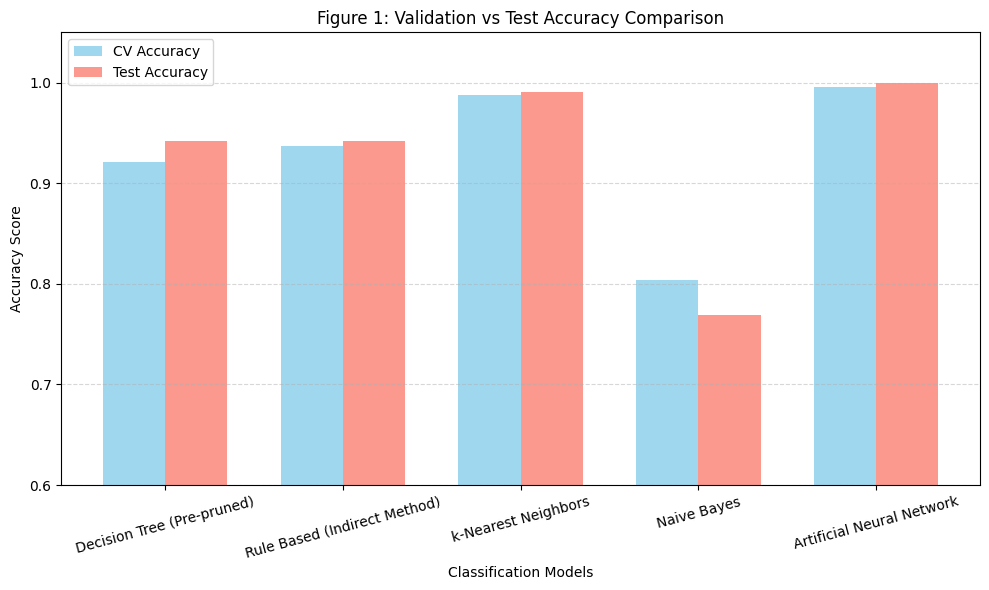

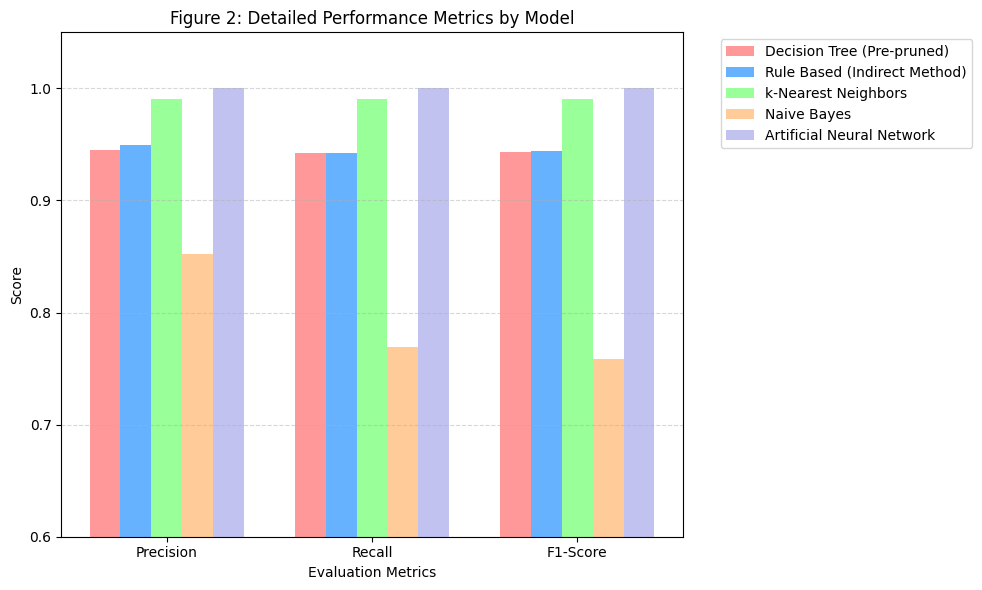

/tmp/ipykernel_882/840649654.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(comparison_df['Model'], rotation=15)
/tmp/ipykernel_882/840649654.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(comparison_df['Model'], rotation=15)


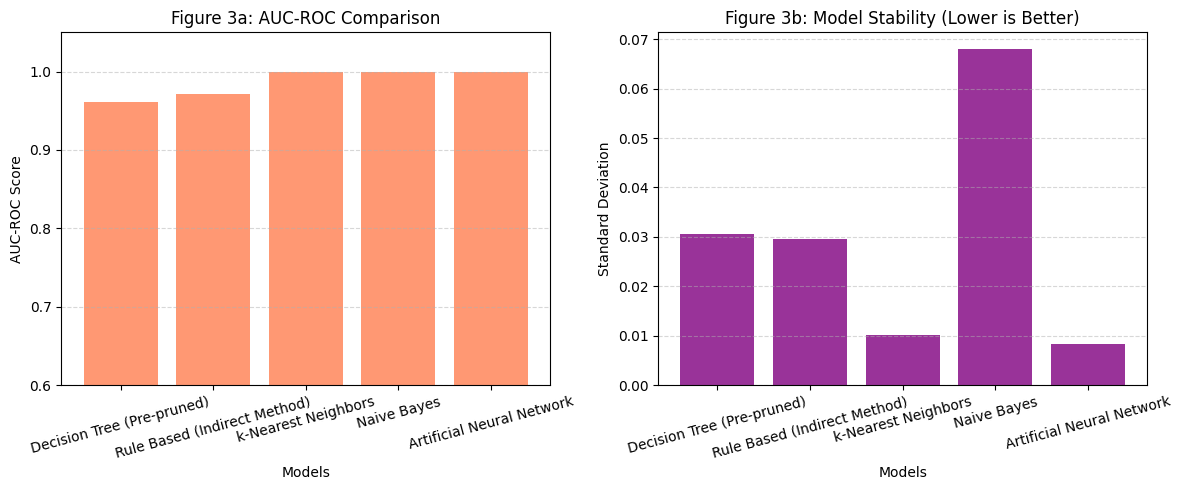

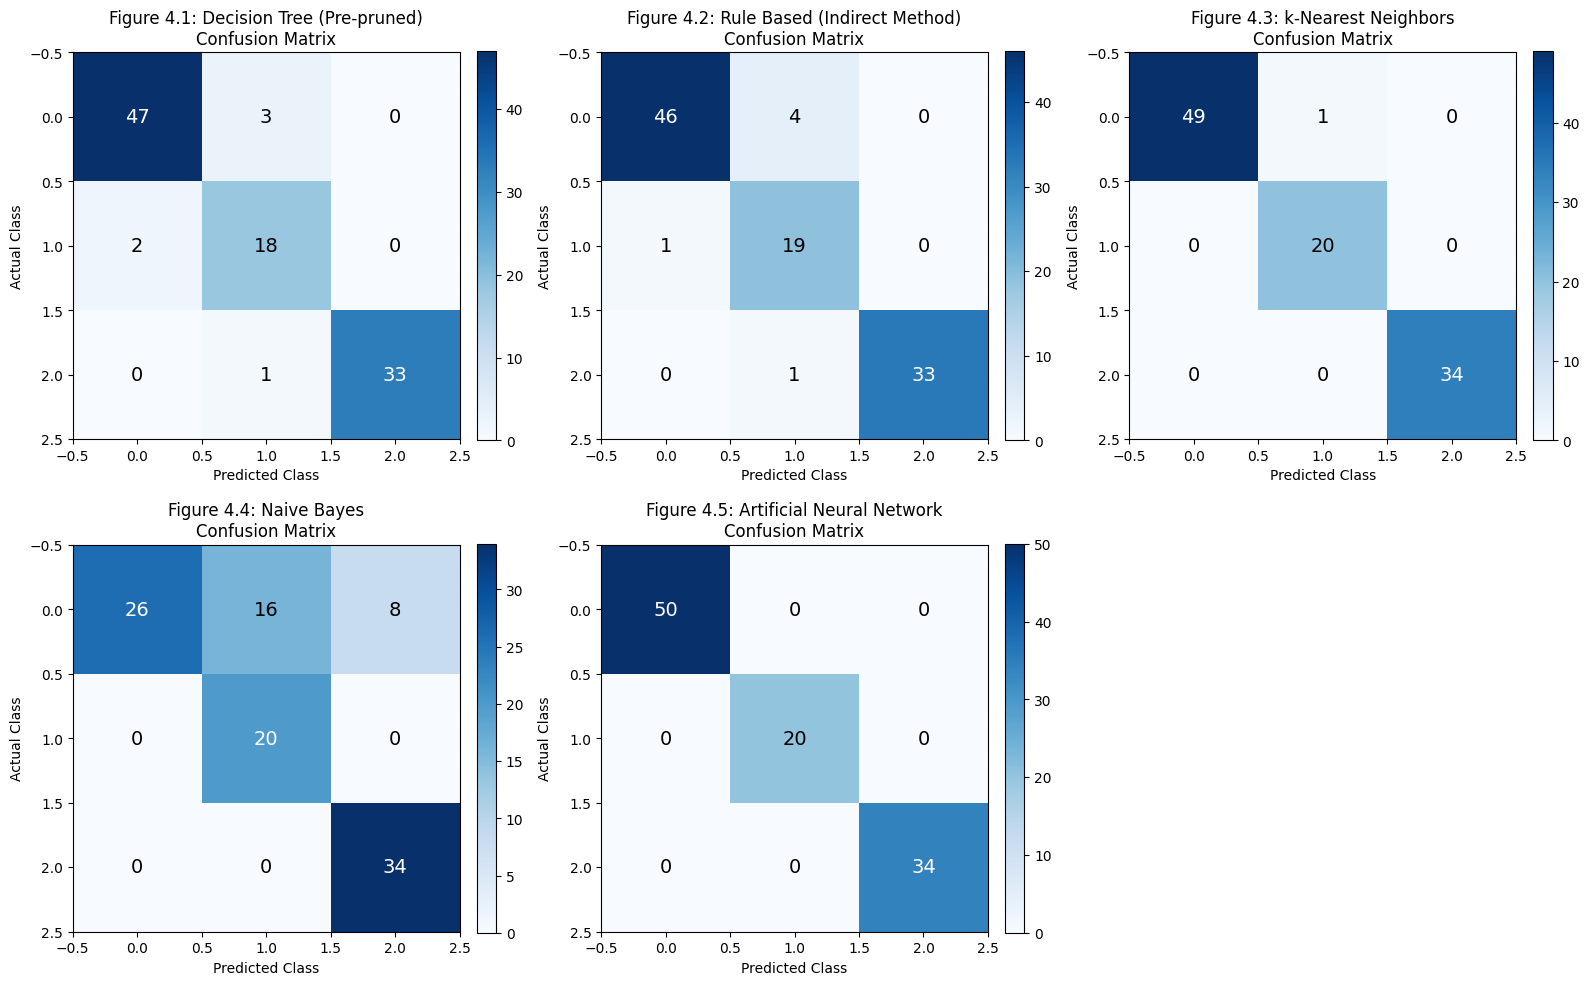

Visualizations generated successfully.


In [7]:
print("\nGenerating Visualizations...\n")

plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.35
plt.bar(x - width/2, comparison_df['CV Accuracy'], width, label='CV Accuracy', alpha=0.8, color='skyblue')
plt.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8, color='salmon')
plt.xlabel('Classification Models')
plt.ylabel('Accuracy Score')
plt.title('Figure 1: Validation vs Test Accuracy Comparison')
plt.xticks(x, comparison_df['Model'], rotation=15)
plt.legend()
plt.ylim(0.6, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.15
multiplier = 0
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#c2c2f0']
for i, model in enumerate(comparison_df['Model']):
    values = [comparison_df.iloc[i][m] for m in metrics_to_plot]
    plt.bar(x + multiplier * width, values, width, label=model, color=colors[i])
    multiplier += 1
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Figure 2: Detailed Performance Metrics by Model')
plt.xticks(x + width * 2, metrics_to_plot)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.6, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(comparison_df['Model'], comparison_df['AUC-ROC'], color='coral', alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('AUC-ROC Score')
ax1.set_title('Figure 3a: AUC-ROC Comparison')
ax1.set_xticklabels(comparison_df['Model'], rotation=15)
ax1.set_ylim(0.6, 1.05)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.bar(comparison_df['Model'], comparison_df['CV Std Dev'], color='purple', alpha=0.8)
ax2.set_xlabel('Models')
ax2.set_ylabel('Standard Deviation')
ax2.set_title('Figure 3b: Model Stability (Lower is Better)')
ax2.set_xticklabels(comparison_df['Model'], rotation=15)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, metrics) in enumerate(metrics_results.items()):
    cm = metrics['confusion_matrix']
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'Figure 4.{idx+1}: {name}\nConfusion Matrix', fontsize=12)
    axes[idx].set_xlabel('Predicted Class')
    axes[idx].set_ylabel('Actual Class')

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                           ha="center", va="center",
                           color="white" if cm[i, j] > thresh else "black",
                           fontsize=14)
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

axes[5].axis('off')

plt.tight_layout()
plt.show()

print("Visualizations generated successfully.")

### Discussion

In this project, we built and compared five different classification models using the Palmer Penguins dataset. We followed a standard data mining pipeline, which included handling missing values with mean imputation, encoding categorical data, and scaling features to make sure all models had a fair playing field. To prevent the models from just memorizing the training data, we used 5-Fold Cross-Validation alongside a 30% test set. When we looked at the results, k-Nearest Neighbors and the Artificial Neural Network came out on top in terms of raw accuracy, which makes sense because they thrive on properly scaled numerical data. On the other hand, Naïve Bayes scored lower, which is expected since its core assumption that all features are completely independent doesn't really hold up with correlated biological measurements like flipper length and body mass. We also used the Indirect Method for our Rule-Based classifier, extracting "If-Then" logic from a shallow Decision Tree to practically demonstrate how rule ordering and default classes work.

### Conclusion

Ultimately, while complex models like the Artificial Neural Network can squeeze out slightly higher accuracy on clean datasets, the Decision Tree proved to be the most practical choice for this project. It delivered highly competitive predictive power while remaining completely interpretable, meaning we can actually trace and understand how it makes its decisions. Overall, this project successfully demonstrated the full classification lifecycle, from data preprocessing and model validation to performance evaluation, highlighting the important trade-offs between raw accuracy and model interpretability in real-world data mining.